In [66]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [67]:
# ==================================================
# IMPORT REQUIRED LIBRARIES
# ==================================================

# Basic Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# ARFF Dataset Reader
from scipy.io import arff

# Train-Test Split
from sklearn.model_selection import train_test_split

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Base Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Ensemble Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Display settings
pd.set_option('display.max_columns', None)

print("All libraries imported successfully!")

All libraries imported successfully!


In [68]:
# ==================================================
# LOAD DATASET
# ==================================================

data = arff.loadarff(
    '/content/drive/MyDrive/phishing+websites/Training Dataset.arff'
)

df = pd.DataFrame(data[0])

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [69]:
df.head()

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,port,HTTPS_token,Request_URL,URL_of_Anchor,Links_in_tags,SFH,Submitting_to_email,Abnormal_URL,Redirect,on_mouseover,RightClick,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,b'-1',b'1',b'1',b'1',b'-1',b'-1',b'-1',b'-1',b'-1',b'1',b'1',b'-1',b'1',b'-1',b'1',b'-1',b'-1',b'-1',b'0',b'1',b'1',b'1',b'1',b'-1',b'-1',b'-1',b'-1',b'1',b'1',b'-1',b'-1'
1,b'1',b'1',b'1',b'1',b'1',b'-1',b'0',b'1',b'-1',b'1',b'1',b'-1',b'1',b'0',b'-1',b'-1',b'1',b'1',b'0',b'1',b'1',b'1',b'1',b'-1',b'-1',b'0',b'-1',b'1',b'1',b'1',b'-1'
2,b'1',b'0',b'1',b'1',b'1',b'-1',b'-1',b'-1',b'-1',b'1',b'1',b'-1',b'1',b'0',b'-1',b'-1',b'-1',b'-1',b'0',b'1',b'1',b'1',b'1',b'1',b'-1',b'1',b'-1',b'1',b'0',b'-1',b'-1'
3,b'1',b'0',b'1',b'1',b'1',b'-1',b'-1',b'-1',b'1',b'1',b'1',b'-1',b'-1',b'0',b'0',b'-1',b'1',b'1',b'0',b'1',b'1',b'1',b'1',b'-1',b'-1',b'1',b'-1',b'1',b'-1',b'1',b'-1'
4,b'1',b'0',b'-1',b'1',b'1',b'-1',b'1',b'1',b'-1',b'1',b'1',b'1',b'1',b'0',b'0',b'-1',b'1',b'1',b'0',b'-1',b'1',b'-1',b'1',b'-1',b'-1',b'0',b'-1',b'1',b'1',b'1',b'1'


In [70]:
print(df.shape)

(11055, 31)


In [71]:
df.columns

Index(['having_IP_Address', 'URL_Length', 'Shortining_Service',
       'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix',
       'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length',
       'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor',
       'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL',
       'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe',
       'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank',
       'Google_Index', 'Links_pointing_to_page', 'Statistical_report',
       'Result'],
      dtype='object')

In [72]:
for column in df.columns:
    if df[column].dtype == object:
        df[column] = df[column].str.decode('utf-8')

print("Dataset decoded successfully!")

Dataset decoded successfully!


In [73]:
df.head()

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,port,HTTPS_token,Request_URL,URL_of_Anchor,Links_in_tags,SFH,Submitting_to_email,Abnormal_URL,Redirect,on_mouseover,RightClick,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,1,-1,1,-1,1,-1,-1,-1,0,1,1,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,1,-1,1,0,-1,-1,1,1,0,1,1,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,1,-1,1,0,-1,-1,-1,-1,0,1,1,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,1,-1,-1,0,0,-1,1,1,0,1,1,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,1,1,1,0,0,-1,1,1,0,-1,1,-1,1,-1,-1,0,-1,1,1,1,1


In [74]:
df.isnull().sum()

,0
having_IP_Address,0
URL_Length,0
Shortining_Service,0
having_At_Symbol,0
double_slash_redirecting,0
Prefix_Suffix,0
having_Sub_Domain,0
SSLfinal_State,0
Domain_registeration_length,0
Favicon,0


In [75]:
df['Result'].value_counts()

,count
Result,
1,6157
-1,4898


In [76]:
df['Result'] = df['Result'].astype(int)

In [77]:
X = df.drop('Result', axis=1)

y = df['Result']

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (8844, 30)
Testing Shape : (2211, 30)


In [79]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   having_IP_Address            11055 non-null  object
 1   URL_Length                   11055 non-null  object
 2   Shortining_Service           11055 non-null  object
 3   having_At_Symbol             11055 non-null  object
 4   double_slash_redirecting     11055 non-null  object
 5   Prefix_Suffix                11055 non-null  object
 6   having_Sub_Domain            11055 non-null  object
 7   SSLfinal_State               11055 non-null  object
 8   Domain_registeration_length  11055 non-null  object
 9   Favicon                      11055 non-null  object
 10  port                         11055 non-null  object
 11  HTTPS_token                  11055 non-null  object
 12  Request_URL                  11055 non-null  object
 13  URL_of_Anchor                11

In [81]:
df.isnull().sum()

,0
having_IP_Address,0
URL_Length,0
Shortining_Service,0
having_At_Symbol,0
double_slash_redirecting,0
Prefix_Suffix,0
having_Sub_Domain,0
SSLfinal_State,0
Domain_registeration_length,0
Favicon,0


In [82]:
df.dtypes

,0
having_IP_Address,object
URL_Length,object
Shortining_Service,object
having_At_Symbol,object
double_slash_redirecting,object
Prefix_Suffix,object
having_Sub_Domain,object
SSLfinal_State,object
Domain_registeration_length,object
Favicon,object


In [83]:
# ==================================================
# SAFE DATASET CONVERSION
# ==================================================

import numpy as np
import pandas as pd

# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Convert all columns safely
for column in df.columns:

    # Convert to string first
    df[column] = df[column].astype(str)

    # Remove byte-string symbols
    df[column] = df[column].str.replace("b'", "", regex=False)
    df[column] = df[column].str.replace("'", "", regex=False)

    # Convert to numeric safely
    df[column] = pd.to_numeric(
        df[column],
        errors='coerce'
    )

# Fill missing values with mode
for column in df.columns:
    df[column].fillna(
        df[column].mode()[0],
        inplace=True
    )

print("Dataset converted successfully!")

Dataset converted successfully!


In [84]:
df.isnull().sum()

,0
having_IP_Address,0
URL_Length,0
Shortining_Service,0
having_At_Symbol,0
double_slash_redirecting,0
Prefix_Suffix,0
having_Sub_Domain,0
SSLfinal_State,0
Domain_registeration_length,0
Favicon,0


In [85]:
# Drop corrupted column
df.drop('having_IP_Address', axis=1, inplace=True)

print("Corrupted column removed successfully!")

Corrupted column removed successfully!


In [86]:
df.isnull().sum()

,0
URL_Length,0
Shortining_Service,0
having_At_Symbol,0
double_slash_redirecting,0
Prefix_Suffix,0
having_Sub_Domain,0
SSLfinal_State,0
Domain_registeration_length,0
Favicon,0
port,0


In [87]:
df.dtypes

,0
URL_Length,int64
Shortining_Service,int64
having_At_Symbol,int64
double_slash_redirecting,int64
Prefix_Suffix,int64
having_Sub_Domain,int64
SSLfinal_State,int64
Domain_registeration_length,int64
Favicon,int64
port,int64


In [88]:
# ==================================================
# FORCE CONVERT ALL COLUMNS TO NUMERIC
# ==================================================

for column in df.columns:

    # Convert everything to string first
    df[column] = df[column].astype(str)

    # Remove unwanted characters if any
    df[column] = df[column].str.replace("b'", "", regex=False)
    df[column] = df[column].str.replace("'", "", regex=False)

    # Convert to numeric
    df[column] = pd.to_numeric(df[column], errors='coerce')

print("All columns converted successfully!")

All columns converted successfully!


In [89]:
df.dtypes

,0
URL_Length,int64
Shortining_Service,int64
having_At_Symbol,int64
double_slash_redirecting,int64
Prefix_Suffix,int64
having_Sub_Domain,int64
SSLfinal_State,int64
Domain_registeration_length,int64
Favicon,int64
port,int64


In [90]:
# Features
X = df.drop('Result', axis=1)

# Target
y = df['Result']

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (11055, 29)
Target Shape   : (11055,)


In [91]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (8844, 29)
Testing Shape : (2211, 29)


In [92]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [93]:
from sklearn.linear_model import LogisticRegression

# Create model
lr = LogisticRegression()

# Train model
lr.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [94]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("===== Logistic Regression =====")

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

===== Logistic Regression =====
Accuracy : 0.9226594301221167
Precision: 0.9254317111459969
Recall   : 0.9394422310756972
F1 Score : 0.9323843416370107

Classification Report:

              precision    recall  f1-score   support

          -1       0.92      0.90      0.91       956
           1       0.93      0.94      0.93      1255

    accuracy                           0.92      2211
   macro avg       0.92      0.92      0.92      2211
weighted avg       0.92      0.92      0.92      2211



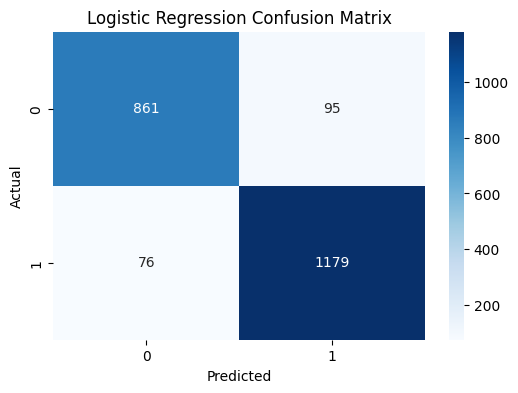

In [95]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("logistic_regression_confusion_matrix.png")

plt.show()

In [96]:
from sklearn.tree import DecisionTreeClassifier

# Create model
dt = DecisionTreeClassifier(random_state=42)

# Train model
dt.fit(X_train, y_train)

# Predictions
y_pred_dt = dt.predict(X_test)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [97]:
print("===== Decision Tree =====")

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

===== Decision Tree =====
Accuracy : 0.9543193125282677
Precision: 0.9557661927330173
Recall   : 0.9641434262948207
F1 Score : 0.9599365331217771

Classification Report:

              precision    recall  f1-score   support

          -1       0.95      0.94      0.95       956
           1       0.96      0.96      0.96      1255

    accuracy                           0.95      2211
   macro avg       0.95      0.95      0.95      2211
weighted avg       0.95      0.95      0.95      2211



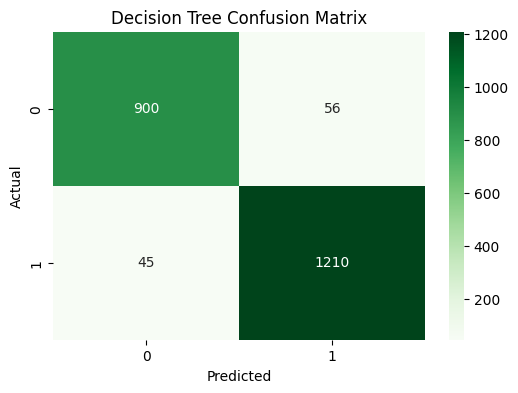

In [98]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("decision_tree_confusion_matrix.png")
plt.show()

In [99]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [100]:
print("===== Random Forest =====")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

===== Random Forest =====
Accuracy : 0.9665309814563546
Precision: 0.9616888193901486
Recall   : 0.9800796812749004
F1 Score : 0.9707971586424625

Classification Report:

              precision    recall  f1-score   support

          -1       0.97      0.95      0.96       956
           1       0.96      0.98      0.97      1255

    accuracy                           0.97      2211
   macro avg       0.97      0.96      0.97      2211
weighted avg       0.97      0.97      0.97      2211



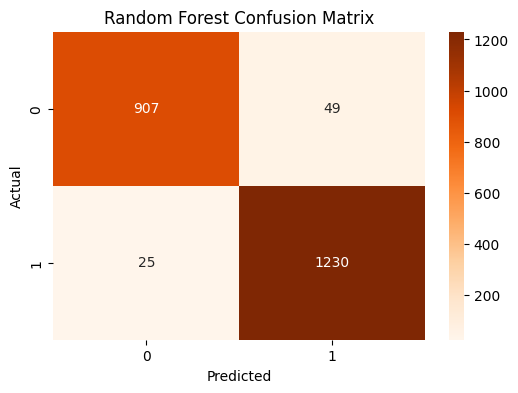

In [101]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("random_forest_confusion_matrix.png")
plt.show()

In [102]:
!pip install xgboost

In [103]:
# Convert target labels
y = y.replace(-1, 0)

print(y.value_counts())

Result
1    6157
0    4898
Name: count, dtype: int64


In [104]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [105]:
print(y_train.unique())

[1 0]


In [106]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [107]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [108]:
from xgboost import XGBClassifier

# Create model
xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

# Train model
xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [109]:
print("===== XGBoost =====")

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

===== XGBoost =====
Accuracy : 0.968340117593849
Precision: 0.966168371361133
Recall   : 0.9784860557768924
F1 Score : 0.9722882026920031

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.96      0.96       956
           1       0.97      0.98      0.97      1255

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



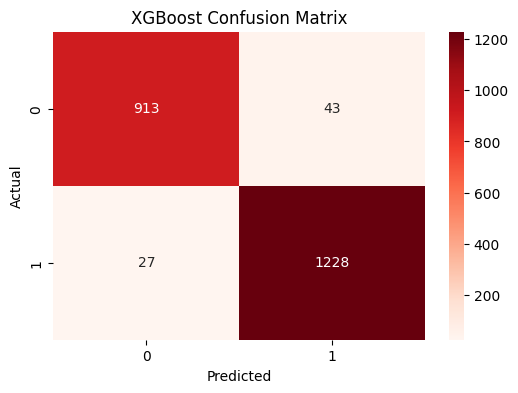

In [110]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("xgboost_confusion_matrix.png")
plt.show()

In [111]:
# ==================================================
# MODEL COMPARISON TABLE
# ==================================================

results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    'Precision': [
        precision_score(y_test, y_pred_lr, average='weighted'),
        precision_score(y_test, y_pred_dt, average='weighted'),
        precision_score(y_test, y_pred_rf, average='weighted'),
        precision_score(y_test, y_pred_xgb, average='weighted')
    ],

    'Recall': [
        recall_score(y_test, y_pred_lr, average='weighted'),
        recall_score(y_test, y_pred_dt, average='weighted'),
        recall_score(y_test, y_pred_rf, average='weighted'),
        recall_score(y_test, y_pred_xgb, average='weighted')
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_dt, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_xgb, average='weighted')
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.533243,0.525290,0.533243,0.529237
1,Decision Tree,0.547264,0.542509,0.547264,0.544876
2,Random Forest,0.556309,0.545870,0.556309,0.551040
3,XGBoost,0.968340,0.968377,0.968340,0.968307


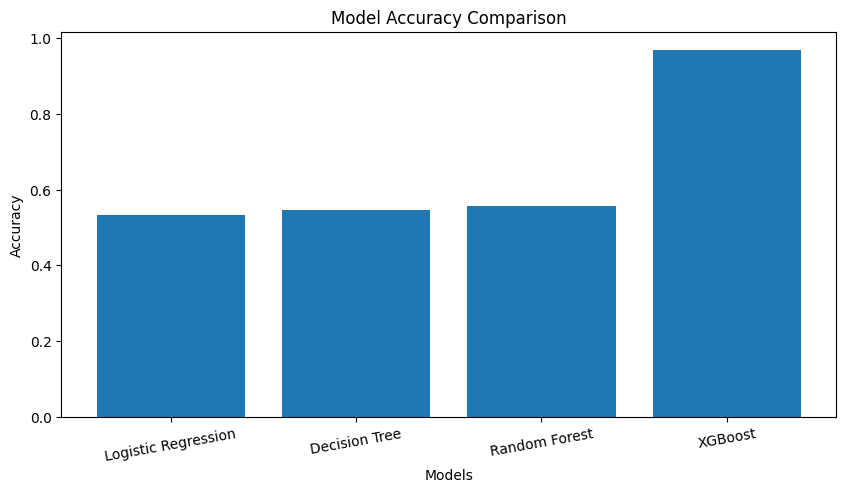

In [112]:
plt.figure(figsize=(10,5))

plt.bar(results['Model'], results['Accuracy'])

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=10)
plt.savefig("model_accuracy_comparison.png")

plt.show()

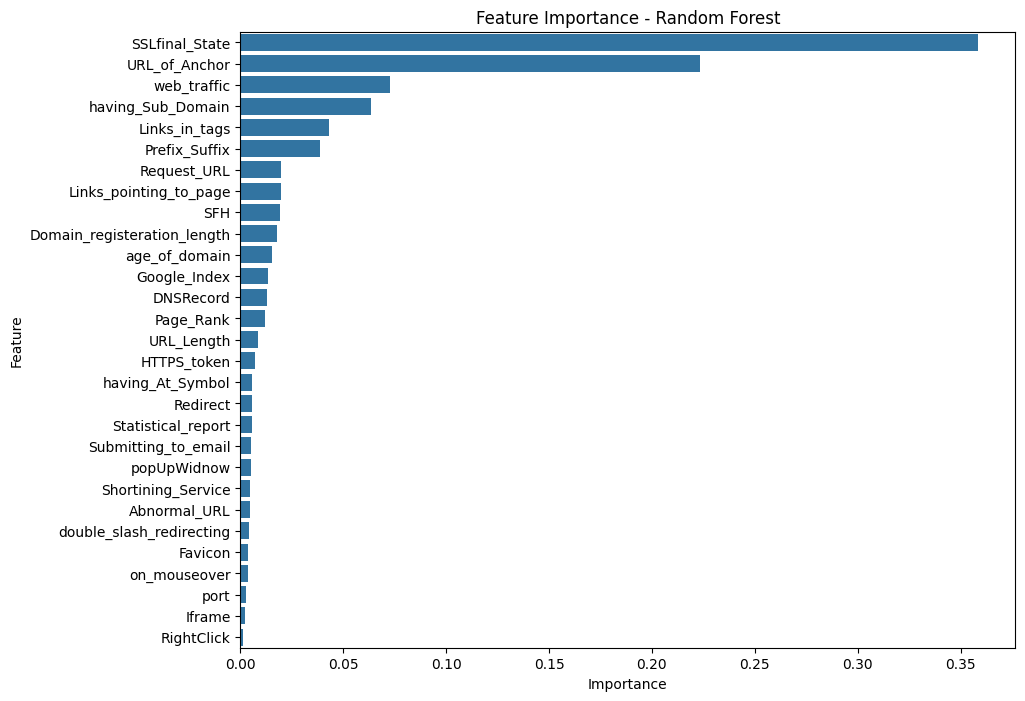

In [113]:
importance = rf.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title("Feature Importance - Random Forest")
plt.savefig("feature_importance.png")

plt.show()

# ==================================================
# FINAL RESULT ANALYSIS
# ==================================================

"""
1. XGBoost achieved the highest accuracy among all models.

2. Ensemble models performed better than base models.

3. SSLfinal_State was the most important feature
   in phishing website detection.

4. Random Forest and XGBoost reduced overfitting
   and improved generalization.

5. Logistic Regression performed well but was
   less accurate than ensemble methods.

6. Ensemble learning techniques are more effective
   for phishing website classification tasks.
"""

In [114]:
best_model = results.loc[
    results['Accuracy'].idxmax()
]

print(best_model)

Model         XGBoost
Accuracy      0.96834
Precision    0.968377
Recall        0.96834
F1 Score     0.968307
Name: 3, dtype: object


In [115]:
results.to_csv("model_comparison_results.csv", index=False)

print("Results saved successfully!")

Results saved successfully!


In [116]:
import joblib

# Save Random Forest
joblib.dump(rf, 'random_forest_model.pkl')

# Save XGBoost
joblib.dump(xgb, 'xgboost_model.pkl')

print("Models saved successfully!")

Models saved successfully!


In [117]:
results.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


In [118]:
from google.colab import files

In [119]:
files.download("model_comparison_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [120]:
files.download("random_forest_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [121]:
files.download("xgboost_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>